# Layer 7, Day 21: downstream 3-arm experiment - setup only

This notebook sets up everything the spec requires to exist BEFORE Day 22
trains and evaluates anything: the held-out evaluation boundary (and its
validator), the classical augmentation arm specified in full, and the
pre-registered benefit margin + harm tolerance. No arm is trained here -
that is Day 22's job, and per spec, if any of these numbers changed after
seeing a result, that would have to be stated in writing and rerun. Writing
them now, before any training, is the whole point.


## 1. The three arms and the held-out evaluation boundary

- **(a) real-only** - trained on real TRAIN-split patches only.
- **(b) real + classical augmentation** - same real patches, plus a fully
  specified augmentation pipeline (every transform, every probability -
  see section 2).
- **(c) real + synthetic** - real patches plus patches from images
  generated by `sample_coarse_to_fine`, generated ONLY from TRAIN sources.

All three arms are evaluated on the **VALIDATION** split - groups no
generator and no training arm may ever touch. This is enforced by
`data.guard.assert_lineage_avoids_holdout`, a NEW validator (distinct from
the existing hidden-TEST guard, which protects a different boundary).

In [1]:
import sys, os
sys.path.append(os.path.join("..", "..", "src"))
import json
import numpy as np

from data.guard import assert_lineage_avoids_holdout, HoldoutLeakageError, VALIDATION_IDS, VALIDATION_SOURCES
from data.loader import TRAIN_IDS

print(f"held-out evaluation set: {len(VALIDATION_IDS)} images / {len(VALIDATION_SOURCES)} DOI groups")
print(f"available for training (all 3 arms): {len(TRAIN_IDS)} TRAIN images")


held-out evaluation set: 56 images / 37 DOI groups
available for training (all 3 arms): 310 TRAIN images


### Proving the holdout validator actually fires

Per spec: "assert it in a validator, and test the validator against a
deliberately contaminated record" - a validator that has never failed has
not been tested.

In [2]:
clean_lineage = TRAIN_IDS[:3]
assert_lineage_avoids_holdout(clean_lineage)
print(f"clean (TRAIN-only) lineage passed: {clean_lineage}")

contaminated_lineage = TRAIN_IDS[:2] + [sorted(VALIDATION_IDS)[0]]
try:
    assert_lineage_avoids_holdout(contaminated_lineage)
    raise SystemExit("BUG: a lineage contaminated with a held-out VALIDATION image was NOT rejected")
except HoldoutLeakageError as e:
    print(f"correctly rejected: {e}")


clean (TRAIN-only) lineage passed: ['00655d9628', '0144266d21', '01ac659240']
correctly rejected: generation lineage touches a held-out evaluation group: ['0113230c21']. The run is void - not flagged, void.


## 2. Arm (b): the classical augmentation pipeline, specified in full

Per spec: "Specify arm (b) fully - every transform and every probability.
An under-specified classical baseline is the second most common way these
results are overstated, because the weak baseline does the work."
`src/data/augmentation.py::CONFIG` is the single source of truth - printed
here directly, not retyped, so this notebook can never drift from the
actual code that runs in Day 22.

In [3]:
from data.augmentation import CONFIG, classical_augment

print(json.dumps(CONFIG, indent=2))


{
  "horizontal_flip": {
    "p": 0.5
  },
  "vertical_flip": {
    "p": 0.5
  },
  "rotate_90": {
    "p": 0.5,
    "k_choices": [
      1,
      2,
      3
    ]
  },
  "gaussian_noise": {
    "p": 0.3,
    "sigma": 5.0
  },
  "brightness_scale": {
    "p": 0.3,
    "low": 0.9,
    "high": 1.1
  }
}


### Demonstrated on one real patch

Not just a config dump - the pipeline actually applied to a real EMPS
patch, deterministically, so its effect is visible, not just declared.

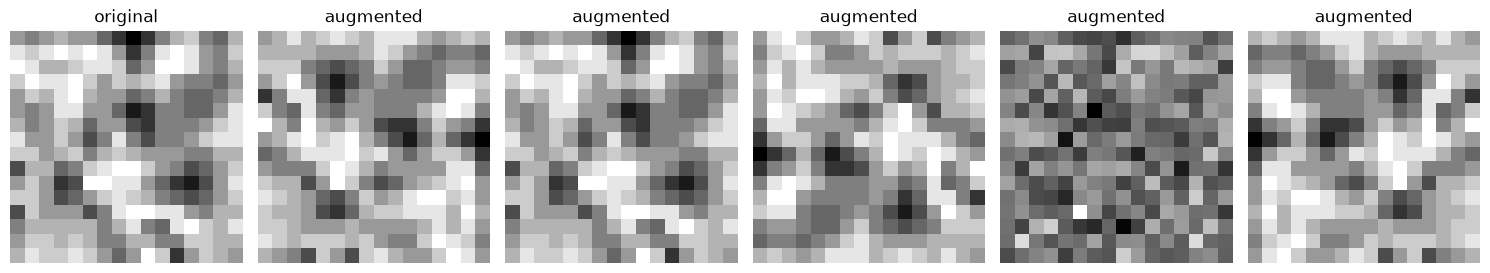

saved ..\..\results\figures\classical_augmentation_examples.png


In [4]:
import matplotlib.pyplot as plt
from data.loader import DEV_SOURCE_IDS, load_generator_source
from data.patches import extract_patches

demo_img, _ = load_generator_source(DEV_SOURCE_IDS[0])
demo_patch = extract_patches(demo_img[:64, :64], patch_size=16, stride=16).patches[0].astype(np.float64)

rng = np.random.default_rng(0)
augmented_examples = [classical_augment(demo_patch, rng) for _ in range(5)]

fig, axes = plt.subplots(1, 6, figsize=(15, 3))
axes[0].imshow(demo_patch, cmap="gray"); axes[0].set_title("original"); axes[0].axis("off")
for ax, ex in zip(axes[1:], augmented_examples):
    ax.imshow(np.clip(ex, 0, 255), cmap="gray"); ax.set_title("augmented"); ax.axis("off")
plt.tight_layout()

fig_path = os.path.join("..", "..", "results", "figures", "classical_augmentation_examples.png")
plt.savefig(fig_path, dpi=100, bbox_inches="tight")
plt.show()
print(f"saved {fig_path}")


## 3. Equal update budget and pre-registered thresholds

Written to `configs/experiments/downstream_preregistration_v1.json` BEFORE
Day 22 runs anything - loaded here, not retyped, for the same
never-drifts-from-the-actual-file reason as section 2.

In [5]:
prereg_path = os.path.join("..", "..", "configs", "experiments", "downstream_preregistration_v1.json")
with open(prereg_path, encoding="utf-8") as f:
    prereg = json.load(f)

print(json.dumps(prereg, indent=2))


{
  "registered_before_run": "Day 21 - written before Day 22's arms are trained or evaluated",
  "task": "binary patch classifier: does an 8x8 EMPS patch contain particle pixels (from the real segmap) or is it pure background",
  "model": "single-hidden-layer MLP (small, CPU-trainable), trained with plain SGD",
  "arms": {
    "a_real_only": "patches from TRAIN-split images only",
    "b_real_plus_classical_aug": "TRAIN-split patches + src/data/augmentation.py::classical_augment applied per-batch",
    "c_real_plus_synthetic": "TRAIN-split patches + patches from images generated by sample_coarse_to_fine, generated ONLY from TRAIN sources (never VALIDATION or TEST)"
  },
  "equal_update_budget": {
    "total_gradient_steps": 500,
    "batch_size": 32,
    "optimizer": "SGD",
    "learning_rate": 0.01,
    "rule": "identical total_gradient_steps, batch_size, optimizer and learning_rate across all three arms - no exceptions, per spec rule 14"
  },
  "held_out_evaluation_set": {
    "split

## Layer 7, Day 21 status

- [x] Held-out evaluation boundary defined (VALIDATION split: 37 DOI groups,
  56 images) and enforced by a NEW validator (`assert_lineage_avoids_holdout`),
  proven to fire on a deliberately contaminated record.
- [x] Arm (b)'s classical augmentation fully specified (5 named transforms,
  each with an explicit probability, all in `src/data/augmentation.py`) and
  demonstrated on a real patch.
- [x] Equal optimizer update budget fixed BEFORE any arm trains: 500
  gradient steps, batch_size=32, SGD, lr=0.01 - identical across all 3 arms.
- [x] Benefit margin (+2.0 pp) and harm tolerance (-1.0 pp) pre-registered
  in `configs/experiments/downstream_preregistration_v1.json`, written
  before Day 22 trains or evaluates anything.
- Not done here (by design - this is setup, not execution): no arm has
  been trained, no synthetic images for arm (c) have been generated yet,
  no bootstrap-over-groups evaluation has been run. That is Day 22.
